In [1]:
1

1

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd
import numpy as np





In [3]:

data_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "heart-disease/processed.cleveland.data"
)

col_names = [
    "age",          
    "sex",          
    "cp",          
    "trestbps",     
    "chol",        
    "fbs",          
    "restecg",      
    "thalach",     
    "exang",        
    "oldpeak",      
    "slope",        
    "ca",           
    "thal",         
    "num",          
]

heart_df = pd.read_csv(
    data_url,
    names=col_names,
    na_values="?",
    dtype="float64",   
)

print( heart_df.shape)
print(heart_df.head())



(303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  num  
0    3.0  0.0   6.0  0.0  
1    2.0  3.0   3.0  2.0  
2    2.0  2.0   7.0  1.0  
3    3.0  0.0   3.0  0.0  
4    1.0  0.0   3.0  0.0  


In [4]:
missing_values = heart_df.isna().sum()
missing_values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [5]:
df_clean = heart_df.copy()

df_clean["ca"].fillna(df_clean["ca"].mode()[0], inplace=True)
df_clean["thal"].fillna(df_clean["thal"].mode()[0], inplace=True)

print(df_clean.isna().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


C:\Users\hwi\AppData\Local\Temp\ipykernel_11500\2680403351.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["ca"].fillna(df_clean["ca"].mode()[0], inplace=True)
C:\Users\hwi\AppData\Local\Temp\ipykernel_11500\2680403351.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  num       303 non-null    float64
dtypes: float64(14)
memory usage: 33.3 KB


In [7]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    float64
dtypes: float64(14)
memory usage: 33.3 KB


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np



In [9]:


categorical_features = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"
]
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

X = df_clean.drop("num", axis=1)
y = (df_clean["num"] > 0).astype(int)

X_processed = preprocessor.fit_transform(X)

print("After Encoding and Scaling:", X_processed.shape)


After Encoding and Scaling: (303, 28)


In [10]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

print("Basic Statistics for Numerical Features:\n")
print(df_clean[numeric_features].describe())


Basic Statistics for Numerical Features:

              age    trestbps        chol     thalach     oldpeak
count  303.000000  303.000000  303.000000  303.000000  303.000000
mean    54.438944  131.689769  246.693069  149.607261    1.039604
std      9.038662   17.599748   51.776918   22.875003    1.161075
min     29.000000   94.000000  126.000000   71.000000    0.000000
25%     48.000000  120.000000  211.000000  133.500000    0.000000
50%     56.000000  130.000000  241.000000  153.000000    0.800000
75%     61.000000  140.000000  275.000000  166.000000    1.600000
max     77.000000  200.000000  564.000000  202.000000    6.200000


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


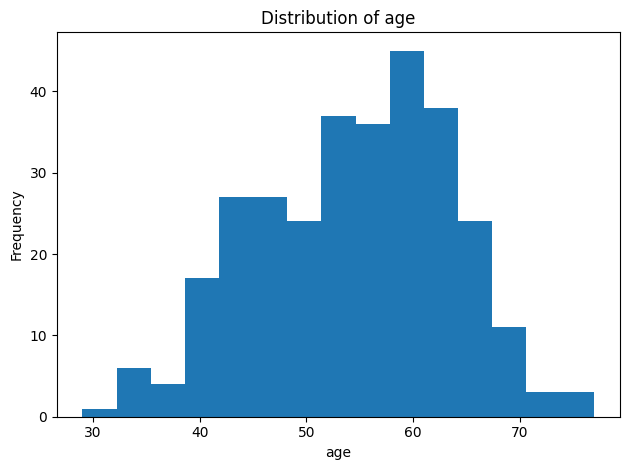

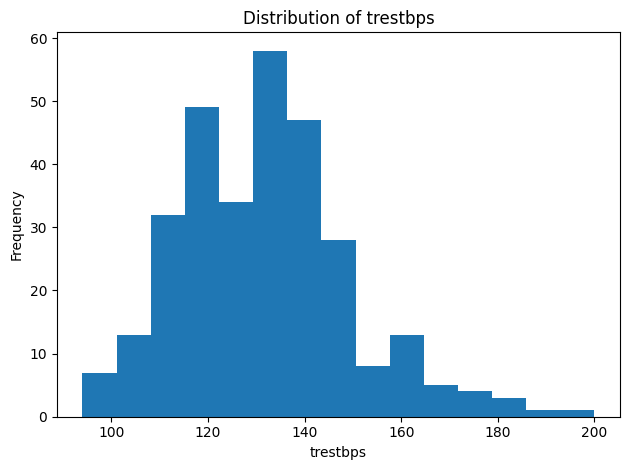

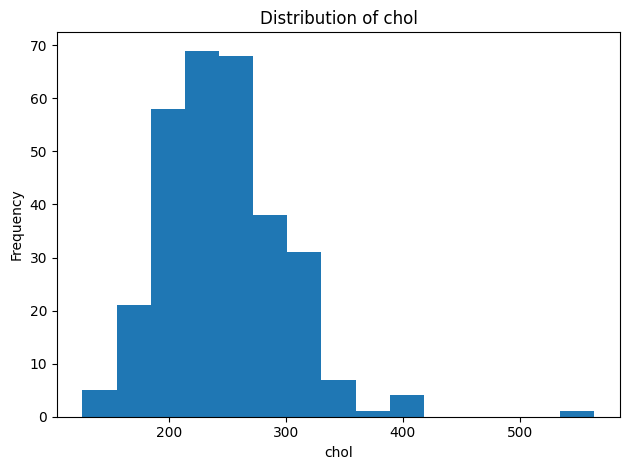

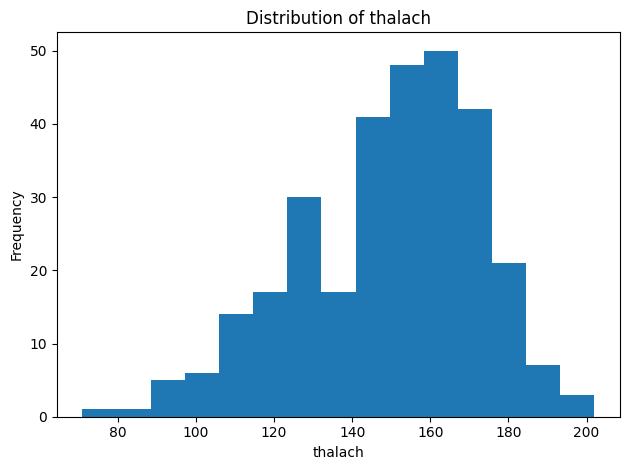

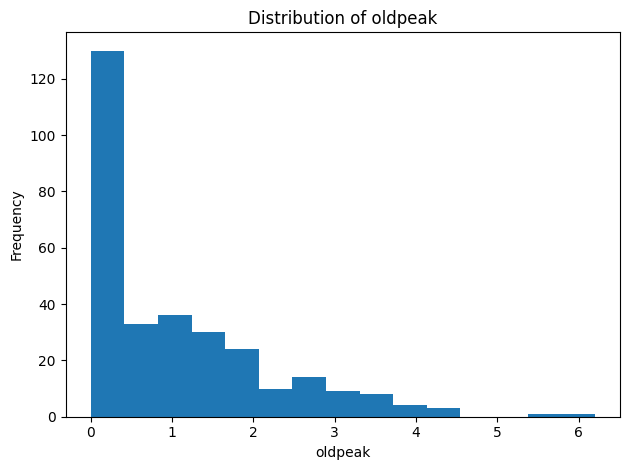

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [11]:

stats = df_clean[numeric_features].describe().T   
display(stats)   


for col in numeric_features:
    plt.figure()                  
    plt.hist(df_clean[col].dropna(), bins=15)  
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


plt.figure()



In [12]:

ks = [2, 5, 10]
inits = {"random": "random", "k-means++": "k-means++"}
n_init = 10
rng = 42

records = []

for k in ks:
    for init_name, init_method in inits.items():
        km = KMeans(
            n_clusters=k,
            init=init_method,
            n_init=n_init,
            random_state=rng,
        )
        labels = km.fit_predict(X_processed)

        inertia     = km.inertia_
        sil         = silhouette_score(X_processed, labels) if k > 1 else np.nan
        sizes       = pd.Series(labels).value_counts().sort_index().to_dict()
        n_iter      = km.n_iter_            
        max_iter    = km.max_iter           

        records.append(
            {
                "K": k,
                "Init": init_name,
                "Inertia": inertia,
                "Silhouette": sil,
                "Iterations": n_iter,
                "Max_iter": max_iter,
                "Cluster sizes": sizes,
            }
        )

results_df = pd.DataFrame(records)
pd.set_option("display.max_colwidth", 100)
print("\n===== K-Means Iterations to Convergence =====\n")
print(results_df.to_string(index=False))


c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:


===== K-Means Iterations to Convergence =====

 K      Init     Inertia  Silhouette  Iterations  Max_iter                                                          Cluster sizes
 2    random 2250.934830    0.164147           8       300                                                       {0: 138, 1: 165}
 2 k-means++ 2250.806386    0.165177           8       300                                                       {0: 137, 1: 166}
 5    random 1863.351409    0.098714          13       300                                    {0: 59, 1: 46, 2: 46, 3: 70, 4: 82}
 5 k-means++ 1864.561704    0.107448          11       300                                    {0: 94, 1: 39, 2: 53, 3: 48, 4: 69}
10    random 1600.362853    0.085485           9       300 {0: 34, 1: 29, 2: 46, 3: 38, 4: 27, 5: 21, 6: 35, 7: 28, 8: 24, 9: 21}
10 k-means++ 1602.370232    0.087326          21       300 {0: 23, 1: 18, 2: 29, 3: 30, 4: 17, 5: 35, 6: 20, 7: 33, 8: 31, 9: 67}


In [21]:

best_k      = 2         
best_init   = "k-means++"
n_init      = 10
random_seed = 42

km = KMeans(
    n_clusters=best_k,
    init=best_init,
    n_init=n_init,
    random_state=random_seed
)

cluster_labels = km.fit_predict(X_processed)   

df_with_clusters = df_clean.copy()
df_with_clusters["cluster"] = cluster_labels

print("First 10 rows with cluster labels:")
print(df_with_clusters.head(10))

cluster_sizes = df_with_clusters["cluster"].value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_sizes)

ct = pd.crosstab(df_with_clusters["cluster"], y, 
                 rownames=["Cluster"], colnames=["Disease (num>0)"])
print("\nContingency table of clusters vs disease presence:")
print(ct)


First 10 rows with cluster labels:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
5  56.0  1.0  2.0     120.0  236.0  0.0      0.0    178.0    0.0      0.8   
6  62.0  0.0  4.0     140.0  268.0  0.0      2.0    160.0    0.0      3.6   
7  57.0  0.0  4.0     120.0  354.0  0.0      0.0    163.0    1.0      0.6   
8  63.0  1.0  4.0     130.0  254.0  0.0      2.0    147.0    0.0      1.4   
9  53.0  1.0  4.0     140.0  203.0  1.0      2.0    155.0    1.0      3.1   

   slope   ca  thal  num  cluster  
0    3.0  0.0   6.0  0.0        0  
1    2.0  3.0   3.0  2.0        0  
2    2.0 

C:\Users\hwi\AppData\Local\Temp\ipykernel_11500\1872592922.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_clusters))
C:\Users\hwi\AppData\Local\Temp\ipykernel_11500\1872592922.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


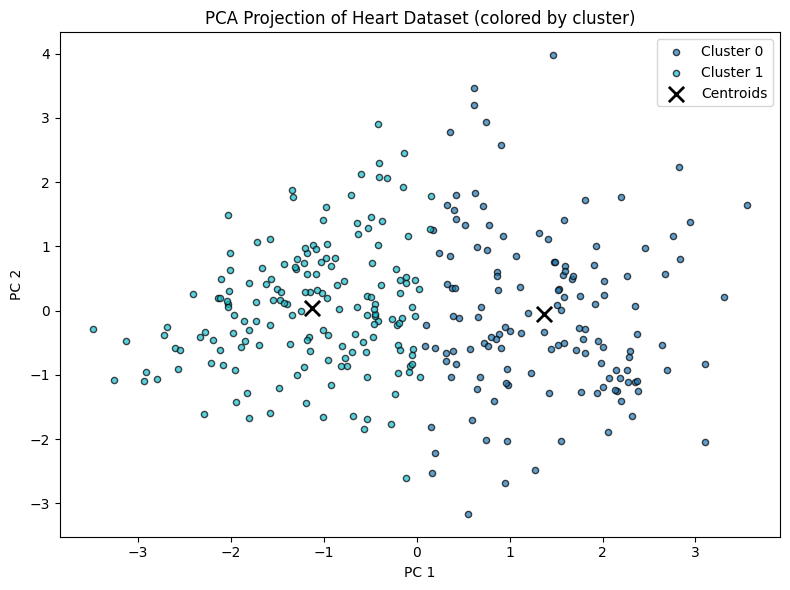

In [ ]:


if not isinstance(X_processed, np.ndarray):
    X_dense = X_processed.toarray()
else:
    X_dense = X_processed

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_dense)

unique_clusters = np.unique(cluster_labels)
cmap = plt.cm.get_cmap("tab10", len(unique_clusters))  

fig, ax = plt.subplots(figsize=(8, 6))

for cl in unique_clusters:
    mask = cluster_labels == cl
    ax.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=f"Cluster {cl}",
        s=20,
        alpha=0.7,
        cmap=cmap,
        c=[cmap(cl)],
        edgecolors="k",
    )

try:
    centers_2d = pca.transform(km.cluster_centers_)
    ax.scatter(
        centers_2d[:, 0],
        centers_2d[:, 1],
        marker="x",
        s=120,
        linewidths=2,
        color="black",
        label="Centroids",
    )
except NameError:
    pass  

ax.set_title("PCA Projection of Heart Dataset (colored by cluster)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend()
plt.tight_layout()
plt.show()


In [23]:
ks        = [2, 5, 10]
init_dict = {"random": "random", "k-means++": "k-means++"}
n_init    = 10
seed      = 42


X_dense = X_processed.toarray() if not isinstance(X_processed, np.ndarray) else X_processed

records = []

for k in ks:
    for init_name, init_method in init_dict.items():
        km = KMeans(
            n_clusters=k,
            init=init_method,
            n_init=n_init,
            random_state=seed,
        )
        labels = km.fit_predict(X_dense)

        sil = silhouette_score(X_dense, labels) if k > 1 else np.nan

        records.append(
            {
                "K": k,
                "Init": init_name,
                "Inertia": km.inertia_,
                "Silhouette": sil,
                "Iterations": km.n_iter_,
            }
        )



results_df = pd.DataFrame(records)
print("\n===== Silhouette Scores for K-Means / K-Means++ =====\n")
print(results_df.to_string(index=False))



===== Silhouette Scores for K-Means / K-Means++ =====

 K      Init     Inertia  Silhouette  Iterations
 2    random 2250.934830    0.164147           8
 2 k-means++ 2250.806386    0.165177           8
 5    random 1863.351409    0.098714          13
 5 k-means++ 1864.561704    0.107448          11
10    random 1600.362853    0.085485           9
10 k-means++ 1602.370232    0.087326          21


In [ ]:


ks        = [2, 5, 10]
init_dict = {"random": "random", "k-means++": "k-means++"}
n_init    = 10
seed      = 42

X_dense = X_processed.toarray() if not isinstance(X_processed, np.ndarray) else X_processed

records = []

for k in ks:
    for init_name, init_method in init_dict.items():
        km = KMeans(
            n_clusters=k,
            init=init_method,
            n_init=n_init,
            random_state=seed,
        )
        labels = km.fit_predict(X_dense)

        sil  = silhouette_score(X_dense, labels) if k > 1 else np.nan
        ari  = adjusted_rand_score(y, labels)   
        iters = km.n_iter_

        records.append(
            {
                "K": k,
                "Init": init_name,
                "Inertia": km.inertia_,
                "Silhouette": sil,
                "ARI": ari,
                "Iterations": iters,
            }
        )


results_df = pd.DataFrame(records).round(4)
print("\n===== Clustering Metrics (Silhouette & ARI) =====\n")
print(results_df.to_string(index=False))



===== Clustering Metrics (Silhouette & ARI) =====

 K      Init   Inertia  Silhouette    ARI  Iterations
 2    random 2250.9348      0.1641 0.2525           8
 2 k-means++ 2250.8064      0.1652 0.2730           8
 5    random 1863.3514      0.0987 0.1712          13
 5 k-means++ 1864.5617      0.1074 0.1542          11
10    random 1600.3629      0.0855 0.0898           9
10 k-means++ 1602.3702      0.0873 0.1122          21


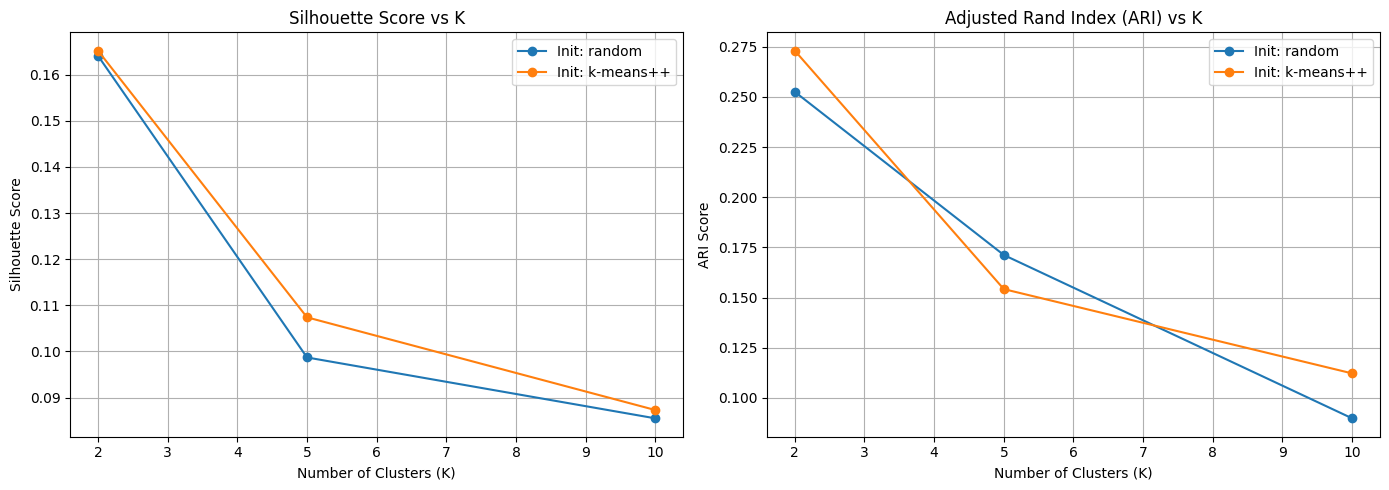

In [25]:
data = {
    "K": [2, 2, 5, 5, 10, 10],
    "Init": ["random", "k-means++", "random", "k-means++", "random", "k-means++"],
    "Silhouette": [0.1641, 0.1652, 0.0987, 0.1074, 0.0855, 0.0873],
    "ARI": [0.2525, 0.2730, 0.1712, 0.1542, 0.0898, 0.1122],
}

df = pd.DataFrame(data)


fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)


for init_method in df["Init"].unique():
    ax[0].plot(
        df[df["Init"] == init_method]["K"],
        df[df["Init"] == init_method]["Silhouette"],
        marker="o",
        label=f"Init: {init_method}"
    )
ax[0].set_title("Silhouette Score vs K")
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("Silhouette Score")
ax[0].legend()
ax[0].grid(True)


for init_method in df["Init"].unique():
    ax[1].plot(
        df[df["Init"] == init_method]["K"],
        df[df["Init"] == init_method]["ARI"],
        marker="o",
        label=f"Init: {init_method}"
    )
ax[1].set_title("Adjusted Rand Index (ARI) vs K")
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("ARI Score")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()